In [41]:
from flextrees.datasets.tabular_datasets import bank
from flextrees.datasets.tabular_datasets import nursery
from flextrees.datasets.tabular_datasets import adult
from flextrees.datasets.tabular_datasets import ildp,magic,credit2,car
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from utils.evaluation import FL_simple_cross_val_score
from sklearn.datasets import load_breast_cancer
import time
import math
from statds.no_parametrics import friedman, bonferroni, nemenyi
import os
import matplotlib.pyplot as plt

In [42]:
datasets = ['bank',
            'adult','nursery','bcancer',
            'ildp','credit','car',
            'covertype','magic','pendig']

In [43]:
datasets2 = ['nursery','car',
            'covertype','pendig']

In [44]:
Nclients = 5

In [45]:
path = os.path.abspath('')

In [46]:
def processDataFrame(dataframe,dataframe1,datasets):
    global_dataframeFed = dataframe[[x for x in dataframe.columns if 'global' in x]]
    global_dataframeNFed =  dataframe1[[x for x in dataframe1.columns if 'global' in x]]
    local_dataframeFed = dataframe[[x for x in dataframe.columns if 'local' in x]]
    local_dataframeNFed =  dataframe1[[x for x in dataframe1.columns if 'local' in x]]
    stats_dataframe = pd.concat([dataframe.iloc[:,0],global_dataframeFed,global_dataframeNFed],axis=1)
    auxglobaldataframe = pd.concat([global_dataframeFed,global_dataframeNFed],axis=1)
    auxlocaldataframe = pd.concat([local_dataframeFed,local_dataframeNFed],axis=1)
    filter = np.array(range(auxglobaldataframe.shape[0])).reshape(-1,6)
    num_datasets = filter.shape[0]
    global_mean = pd.DataFrame(np.nan, index = datasets,
                            columns = auxglobaldataframe.columns)
    local_mean = pd.DataFrame(np.nan, index = datasets,
                            columns = auxlocaldataframe.columns)
    for i in range(num_datasets):
        global_mean.iloc[i] = auxglobaldataframe.iloc[filter[i]].mean(axis=0)
        local_mean.iloc[i] = auxlocaldataframe.iloc[filter[i]].mean(axis=0)
    return stats_dataframe,global_mean,local_mean

In [47]:
distribs= ['iid','niid_quantity_skew','niid_dirichlet_label_skew']
#distribs= ['iid','niid_quantity_skew']

#Nclients=10
statResults = [None]*len(distribs)
for i,distrib in enumerate(distribs):
    dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_acc_'+ str(Nclients))
    dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_other_models_acc_'+ str(Nclients))
    statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets)
    local_mean = local_mean.round(decimals=3)
    global_mean = global_mean.round(decimals=3)
    global_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\global_acc_'+distrib+str(Nclients)+'.csv')
    local_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\local_acc_'+distrib+str(Nclients)+'.csv')
    statResults[i] = statsDataframe



In [48]:
distrib = 'niid_label_quantity_skew'
dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_acc_'+ str(Nclients))
dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_other_models_acc_'+ str(Nclients))
statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets2)
local_mean = local_mean.round(decimals=3)
global_mean = global_mean.round(decimals=3)
global_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\global_acc_'+distrib+str(Nclients)+'.csv')
local_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\local_acc_'+distrib+str(Nclients)+'.csv')
statResults.append(statsDataframe)

# Accuracy IID

In [49]:
statdata = statResults[0]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)



Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 29.023214285714175, p-value 6.022463600241501e-05
{'o_s_Wmv_cw_global': 4.6, 'o_s_Wmv_aw_global': 4.416666666666667, 's_c_b_nb_Wmv_aw_global': 4.358333333333333, 'FRF_global': 3.375, 'DistBoost_global': 2.933333333333333, 'PreWeak_global': 4.066666666666666, 'AdaBoost_global': 4.25}


[4.6, 4.416666666666667, 4.358333333333333, 3.375, 2.933333333333333, 4.066666666666666, 4.25]
1.1628330534552616


C:\Users\mario\AppData\Local\Temp\ipykernel_26496\3334119522.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


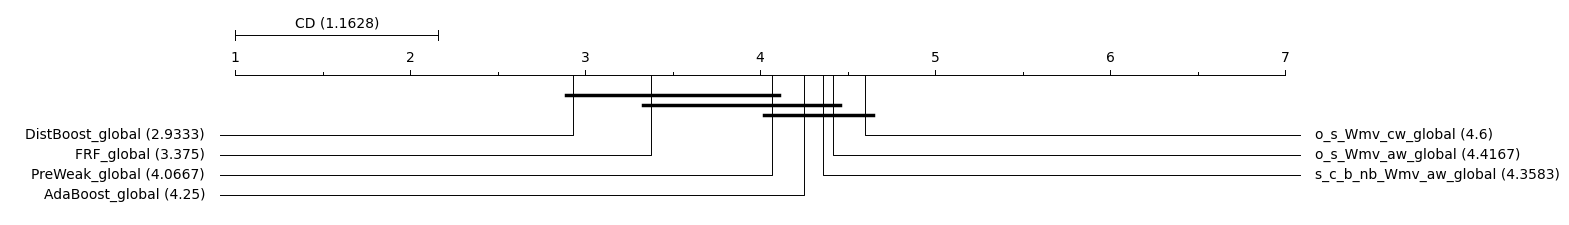

In [50]:

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# Accuracy NIID-QS

In [51]:
statdata = statResults[1]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 18.92857142857133, p-value 0.0042859809416241346
{'o_s_Wmv_cw_global': 4.358333333333333, 'o_s_Wmv_aw_global': 4.675, 's_c_b_nb_Wmv_aw_global': 4.283333333333333, 'FRF_global': 4.0, 'DistBoost_global': 3.8583333333333334, 'PreWeak_global': 3.191666666666667, 'AdaBoost_global': 3.6333333333333333}


[4.358333333333333, 4.675, 4.283333333333333, 4.0, 3.8583333333333334, 3.191666666666667, 3.6333333333333333]
1.1628330534552616


C:\Users\mario\AppData\Local\Temp\ipykernel_26496\3334119522.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


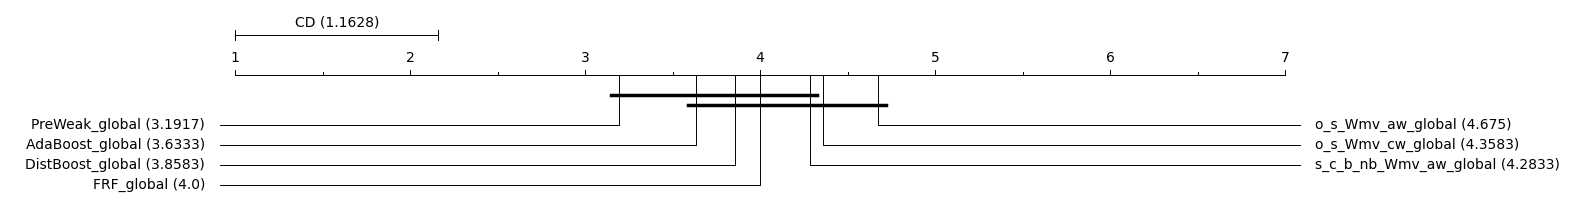

In [52]:

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# Accuracy noIID DLS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 70.92321428571427, p-value 4.09603462259156e-11
{'o_s_Wmv_cw_global': 4.275, 'o_s_Wmv_aw_global': 4.7, 's_c_b_nb_Wmv_aw_global': 5.666666666666667, 'FRF_global': 3.65, 'DistBoost_global': 3.5, 'PreWeak_global': 2.7916666666666665, 'AdaBoost_global': 3.4166666666666665}
[4.275, 4.7, 5.666666666666667, 3.65, 3.5, 2.7916666666666665, 3.4166666666666665]
1.1628330534552616


C:\Users\mario\AppData\Local\Temp\ipykernel_26496\3109710221.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


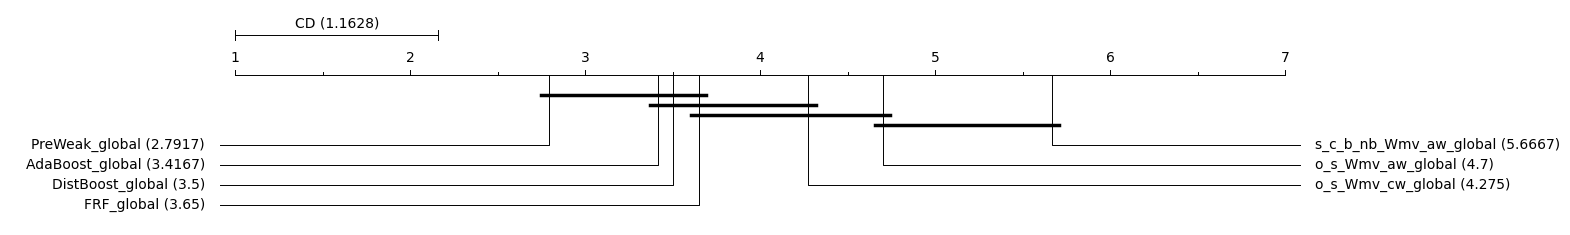

In [53]:
statdata = statResults[2]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# Accuracy noIID DLQS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 39.732142857142776, p-value 5.142137345925946e-07
{'o_s_Wmv_cw_global': 4.5625, 'o_s_Wmv_aw_global': 4.895833333333333, 's_c_b_nb_Wmv_aw_global': 5.625, 'FRF_global': 4.145833333333333, 'DistBoost_global': 3.2916666666666665, 'PreWeak_global': 3.1041666666666665, 'AdaBoost_global': 2.375}
[4.5625, 4.895833333333333, 5.625, 4.145833333333333, 3.2916666666666665, 3.1041666666666665, 2.375]
1.838600493723478


C:\Users\mario\AppData\Local\Temp\ipykernel_26496\1176126289.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


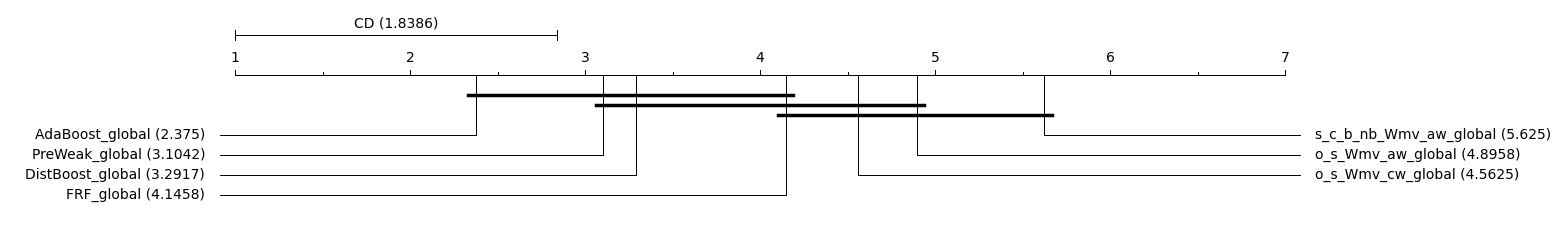

In [54]:
statdata = statResults[3]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# F1 Results

In [55]:
distribs= ['iid','niid_quantity_skew','niid_dirichlet_label_skew']
#distribs= ['iid','niid_quantity_skew']

#Nclients=10
statResults = [None]*len(distribs)
for i,distrib in enumerate(distribs):
    dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_f1_'+ str(Nclients))
    dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_other_models_f1_'+ str(Nclients))
    statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets)
    local_mean = local_mean.round(decimals=3)
    global_mean = global_mean.round(decimals=3)
    global_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\global_f1_'+distrib+str(Nclients)+'.csv')
    local_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\local_f1_'+distrib+str(Nclients)+'.csv')
    statResults[i] = statsDataframe

In [56]:
distrib = 'niid_label_quantity_skew'
dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_f1_'+ str(Nclients))
dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_other_models_f1_'+ str(Nclients))
statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets2)
local_mean = local_mean.round(decimals=3)
global_mean = global_mean.round(decimals=3)
global_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\global_f1_'+distrib+str(Nclients)+'.csv')
local_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\local_f1_'+distrib+str(Nclients)+'.csv')
statResults.append(statsDataframe)

# F1-score IID

Overall comparison:

Fail to Reject H0 with alpha = 0.05 (Same distributions)
Statistic 11.769642857142799, p-value 0.0673095623604365
{'o_s_Wmv_cw_global': 4.05, 'o_s_Wmv_aw_global': 3.8, 's_c_b_nb_Wmv_aw_global': 3.8, 'FRF_global': 4.516666666666667, 'DistBoost_global': 3.375, 'PreWeak_global': 4.041666666666667, 'AdaBoost_global': 4.416666666666667}
[4.05, 3.8, 3.8, 4.516666666666667, 3.375, 4.041666666666667, 4.416666666666667]
1.1628330534552616


C:\Users\mario\AppData\Local\Temp\ipykernel_26496\1993031218.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


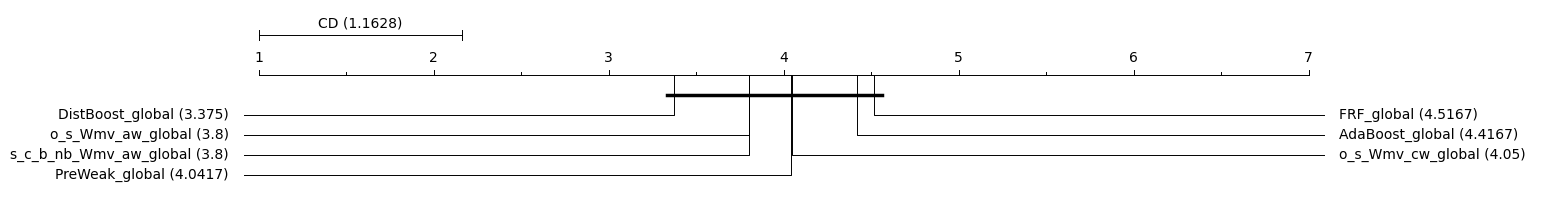

In [57]:
statdata = statResults[0]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# F1-score no-IID QS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 35.00714285714275, p-value 4.295812222387951e-06
{'o_s_Wmv_cw_global': 3.716666666666667, 'o_s_Wmv_aw_global': 3.8833333333333333, 's_c_b_nb_Wmv_aw_global': 3.716666666666667, 'FRF_global': 5.283333333333333, 'DistBoost_global': 4.433333333333334, 'PreWeak_global': 3.183333333333333, 'AdaBoost_global': 3.783333333333333}
[3.716666666666667, 3.8833333333333333, 3.716666666666667, 5.283333333333333, 4.433333333333334, 3.183333333333333, 3.783333333333333]
1.1628330534552616


C:\Users\mario\AppData\Local\Temp\ipykernel_26496\21045223.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


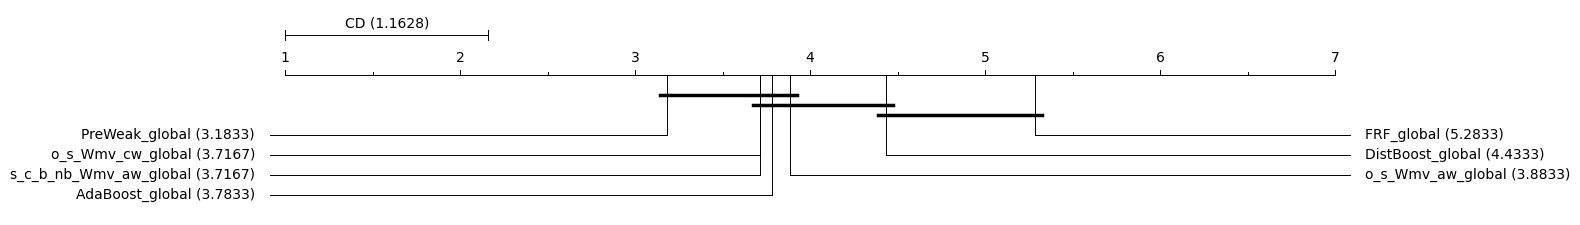

In [58]:
statdata = statResults[1]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# F1-score no-IID DLS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 21.233928571428578, p-value 0.0016652235530472126
{'o_s_Wmv_cw_global': 3.35, 'o_s_Wmv_aw_global': 4.033333333333333, 's_c_b_nb_Wmv_aw_global': 4.216666666666667, 'FRF_global': 4.883333333333334, 'DistBoost_global': 4.066666666666666, 'PreWeak_global': 3.375, 'AdaBoost_global': 4.075}
[3.35, 4.033333333333333, 4.216666666666667, 4.883333333333334, 4.066666666666666, 3.375, 4.075]
1.1628330534552616


C:\Users\mario\AppData\Local\Temp\ipykernel_26496\3559529400.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


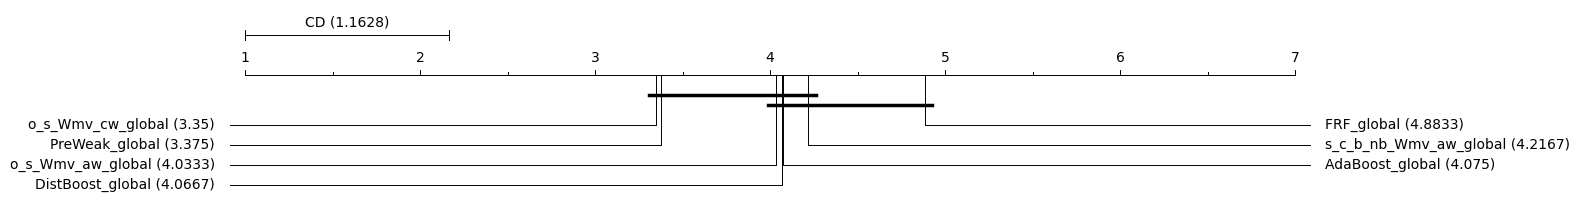

In [59]:
statdata = statResults[2]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# F1-score no-IID DLQS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 16.21875, p-value 0.012626783888758042
{'o_s_Wmv_cw_global': 3.2708333333333335, 'o_s_Wmv_aw_global': 3.5625, 's_c_b_nb_Wmv_aw_global': 4.375, 'FRF_global': 5.375, 'DistBoost_global': 4.208333333333333, 'PreWeak_global': 3.75, 'AdaBoost_global': 3.4583333333333335}


[3.2708333333333335, 3.5625, 4.375, 5.375, 4.208333333333333, 3.75, 3.4583333333333335]
1.838600493723478


C:\Users\mario\AppData\Local\Temp\ipykernel_26496\802260200.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


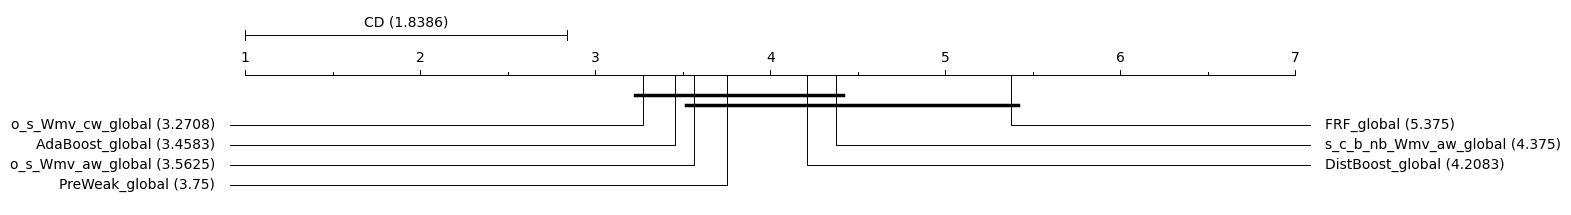

In [60]:
statdata = statResults[3]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()
